# Notebook 4 — Function Approximation & Deep Q-Networks (DQN)

### Course roadmap

1. Foundations & MDPs
2. Dynamic Programming (policy/value iteration)
3. Monte Carlo & Temporal-Difference Learning
4. **Function Approximation & DQN** ← *you are here*
5. Policy Gradients (VPG, REINFORCE, baselines, GAE)
6. Trust Regions: Importance Sampling, KL, TRPO, PPO
7. RLHF for LLMs (SFT → Reward Model → PPO)
8. RLOO & Critic-Free Methods (RLVR)
9. GRPO & the DeepSeek-R1 line of work
10. DPO + Practical Libraries (production PyTorch/`trl` versions of DQN, PPO, RLHF, GRPO)
11. RLCD — RL from Contrastive Distillation (self-generated preference pairs)

As always: **only `numpy` and `matplotlib`**. That includes the neural network.
We write the forward pass, the backpropagation, the gradient check and the Adam
optimizer ourselves, so that when you later see `loss.backward()` and
`optimizer.step()` in PyTorch (notebook 10) you know *exactly* what those two
lines are doing.

### Recap

Notebook 3 gave us algorithms that learn purely from experience — Monte Carlo,
TD(0), SARSA, Q-learning — but every one of them stored its knowledge in a
**table**: one number $V(s)$ per state, or one number $Q(s,a)$ per state-action
pair. Notebook 2 (Section 7) already warned us why that can't last: an LLM's
state is "prompt + everything generated so far," and there are more of those
than atoms in the universe. And notebook 3 (Section 9) promised that a learned
critic is "TD(0) with the table replaced by a neural network." This notebook
makes that promise literal.

### What this notebook covers

- Why tables fail, in two separate ways: **memory** (too many states) and,
  more importantly, **generalization** (a table learns nothing about a state it
  has never visited).
- **Linear function approximation**: $\hat V_w(s) = w^\top x(s)$. We derive the
  *semi-gradient* TD(0) update from a squared-error loss and see precisely why
  it's called "semi."
- A proof-by-experiment that a table is just linear function approximation
  with one-hot features — so everything from notebook 3 is a special case of
  what we do here.
- A **multi-layer perceptron from scratch**: forward pass, backpropagation
  derived by the chain rule, a numerical **gradient check**, and the **Adam**
  optimizer. (We reuse these in notebooks 5 and 6.)
- **CartPole**, a continuous-state control problem, implemented from its
  physics equations in ~30 lines.
- **Deep Q-learning**, why the naive version falls apart (the **deadly
  triad**), and the two fixes that made DQN work: **experience replay** and a
  **target network**.
- **Overestimation bias** of the max operator, and **Double Q-learning / Double
  DQN**.
- Why value-based methods like DQN are *not* how LLMs are trained, and what
  from this notebook carries straight into LLM RL anyway.

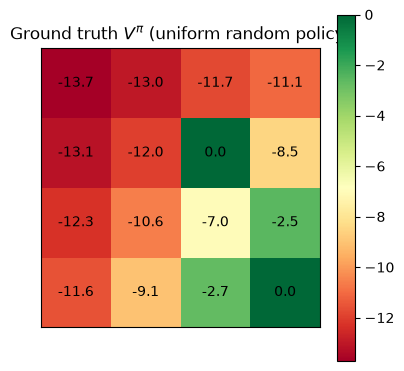

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(0)

class GridWorld:
    '''Same GridWorld as notebooks 1-3, kept self-contained here.'''

    ACTIONS = ["up", "down", "left", "right"]
    ACTION_DELTAS = {
        "up": (-1, 0), "down": (1, 0), "left": (0, -1), "right": (0, 1),
    }

    def __init__(self, height=4, width=4, start=(0, 0), goal=(3, 3), pit=(1, 2),
                 step_reward=-1.0, goal_reward=10.0, pit_reward=-10.0, gamma=0.95):
        self.height, self.width = height, width
        self.start, self.goal, self.pit = start, goal, pit
        self.step_reward, self.goal_reward, self.pit_reward = step_reward, goal_reward, pit_reward
        self.gamma = gamma
        self.all_states = [(r, c) for r in range(height) for c in range(width)]

    def is_terminal(self, rc):
        return rc == self.goal or rc == self.pit

    def step(self, rc, action):
        if self.is_terminal(rc):
            raise ValueError("Cannot step from a terminal state.")
        dr, dc = self.ACTION_DELTAS[action]
        r, c = rc[0] + dr, rc[1] + dc
        if not (0 <= r < self.height and 0 <= c < self.width):
            r, c = rc
        next_rc = (r, c)
        if next_rc == self.goal:
            reward = self.goal_reward
        elif next_rc == self.pit:
            reward = self.pit_reward
        else:
            reward = self.step_reward
        return next_rc, reward, self.is_terminal(next_rc)

env = GridWorld()

def plot_value_grid(env, V, title, ax=None):
    grid = np.array([[V.get((r, c), 0.0) for c in range(env.width)] for r in range(env.height)])
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
    im = ax.imshow(grid, cmap="RdYlGn")
    for r in range(env.height):
        for c in range(env.width):
            ax.text(c, r, f"{grid[r,c]:.1f}", ha="center", va="center")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    if own_fig:
        plt.colorbar(im)
        plt.show()

# --- Ground truth: exact V^pi for the uniform-random policy (notebook 1, Section 5) ---
def exact_V_uniform(env):
    idx_of = {s: i for i, s in enumerate(env.all_states)}
    n = len(env.all_states)
    P_pi, R_pi = np.zeros((n, n)), np.zeros(n)
    for s in env.all_states:
        i = idx_of[s]
        if env.is_terminal(s):
            P_pi[i, i] = 1.0      # absorbing; V = 0 because R = 0 there
            continue
        for a in GridWorld.ACTIONS:
            s_next, reward, _ = env.step(s, a)
            P_pi[i, idx_of[s_next]] += 0.25
            R_pi[i] += 0.25 * reward
    # terminal rows: V(terminal) must be 0, so solve with those rows zeroed
    A = np.eye(n) - env.gamma * P_pi
    for s in env.all_states:
        if env.is_terminal(s):
            i = idx_of[s]; A[i] = 0.0; A[i, i] = 1.0; R_pi[i] = 0.0
    V = np.linalg.solve(A, R_pi)
    return {s: V[idx_of[s]] for s in env.all_states}

V_true = exact_V_uniform(env)
plot_value_grid(env, V_true, "Ground truth $V^\\pi$ (uniform random policy)")

## 1. Why tables die — and it's not (only) about memory

The obvious objection to a table is **memory**: a table over LLM states would
need $|\mathcal V|^L$ entries. True, but there's a subtler and more important
failure, which exists even when the table *would* fit in memory:

> **A table has zero generalization.** Updating $V(s_{17})$ tells you *nothing*
> about $V(s_{18})$, even if $s_{17}$ and $s_{18}$ are nearly identical.

Think about what that means for CartPole (which we build below): the state is
four real numbers — cart position, cart velocity, pole angle, pole angular
velocity. You will essentially *never* visit the exact same state twice. A
table would have one entry per state it has seen, each visited once, each
estimated from a single noisy sample. Useless. What you actually want is:
"the pole is tilting right and falling right — I've seen lots of states *like*
this, and pushing right helped." That "states like this" is **generalization**,
and it requires a *parametric function* whose parameters are shared across
states:

$$
V(s) \;\approx\; \hat V_w(s), \qquad w \in \mathbb R^d,\quad d \ll |\mathcal S|.
$$

Now an update to $w$ caused by one state changes the prediction for *every*
state — ideally in a helpful way for similar states. This is the trade we're
making, stated plainly:

| | Table | Function approximator |
|---|---|---|
| Parameters | one per state | $d$, shared by all states |
| Unseen states | know nothing | predicted by similarity |
| Can it represent $V^\pi$ exactly? | yes | not necessarily (approximation **bias**) |
| Does one update affect other states? | no | **yes** (the whole point — and the whole danger) |

That last row is the source of both the power and the instability of deep RL.
Keep it in mind; it will explain the "deadly triad" in Section 5.

## 2. Linear function approximation, and semi-gradient TD(0)

The simplest parametric function is linear in a **feature vector** $x(s) \in \mathbb R^d$:

$$
\hat V_w(s) = w^\top x(s) = \sum_{i=1}^d w_i\, x_i(s).
$$

The features are your way of describing a state: "how far am I from the
goal?", "am I next to the pit?", and so on.

### Deriving the update

Suppose an oracle told us the true value $V^\pi(s)$. Then learning $w$ is plain
regression: minimize the squared error

$$
\mathcal L(w) = \tfrac12 \big(V^\pi(s) - \hat V_w(s)\big)^2 .
$$

Its gradient is

$$
\nabla_w \mathcal L = -\big(V^\pi(s) - \hat V_w(s)\big)\, \nabla_w \hat V_w(s)
= -\big(V^\pi(s) - \hat V_w(s)\big)\, x(s),
$$

so gradient descent with step size $\alpha$ gives

$$
w \leftarrow w + \alpha \big(V^\pi(s) - \hat V_w(s)\big)\, x(s).
$$

We don't have $V^\pi(s)$. But notebook 3 showed us two stand-ins:

- **Monte Carlo:** use the sampled return $G_t$ (an unbiased sample of $V^\pi(s_t)$).
- **TD(0):** use the bootstrapped target $r_{t+1} + \gamma \hat V_w(s_{t+1})$.

Plug in the TD target and you get **semi-gradient TD(0)**:

$$
\boxed{\;w \leftarrow w + \alpha\, \underbrace{\big(r_{t+1} + \gamma \hat V_w(s_{t+1}) - \hat V_w(s_t)\big)}_{\delta_t \text{ — the same TD error as notebook 3}}\; x(s_t)\;}
$$

### Why "semi"-gradient?

Look at what we did: the target $r + \gamma \hat V_w(s_{t+1})$ *itself depends on
$w$*. A true gradient of $\tfrac12(\text{target} - \hat V_w(s_t))^2$ would also
differentiate through the target, giving an extra term
$\gamma\, x(s_{t+1})$. We deliberately **don't**: we treat the target as a
fixed number, as if it came from an oracle. That is why it's only "semi" a
gradient — it isn't the gradient of any fixed loss function. This matters a
lot:

- It's what makes TD *fast*: we move our prediction toward the target, not the
  target toward our prediction.
- It's also why TD with function approximation has **no general convergence
  guarantee**. We're chasing a target that moves every time we update $w$.
  Section 5 shows what happens when this goes wrong.

In PyTorch this "treat the target as a constant" step is literally
`target.detach()` or `with torch.no_grad():` — you'll see it in every DQN
and PPO implementation in notebook 10.

### A table is a special case

If $x(s)$ is **one-hot** — a vector of length $|\mathcal S|$ with a single 1 at
position $s$ — then $w^\top x(s) = w_s$. That's just a table lookup. The update
$w \leftarrow w + \alpha\delta_t x(s_t)$ changes only $w_{s_t}$, by exactly
$\alpha\delta_t$. **That is notebook 3's tabular TD(0), line for line.** Let's
confirm it.

In [2]:
def one_hot_features(env):
    idx = {s: i for i, s in enumerate(env.all_states)}
    def x(s):
        v = np.zeros(len(env.all_states)); v[idx[s]] = 1.0
        return v
    return x

def coarse_features(env):
    '''Four hand-designed features plus a bias term -- d = 5 parameters for 16 states.'''
    gr, gc = env.goal; pr, pc = env.pit
    def x(s):
        r, c = s
        dist_goal = (abs(r - gr) + abs(c - gc)) / (env.height + env.width - 2)
        dist_pit = (abs(r - pr) + abs(c - pc)) / (env.height + env.width - 2)
        return np.array([1.0, r / (env.height - 1), c / (env.width - 1), dist_goal, dist_pit])
    return x

def semi_gradient_td0(env, feature_fn, alpha, n_episodes=5000, max_steps=50, seed=0):
    rng = np.random.default_rng(seed)
    d = len(feature_fn(env.start))
    w = np.zeros(d)
    for _ in range(n_episodes):
        s = env.start
        for _ in range(max_steps):
            a = GridWorld.ACTIONS[rng.integers(4)]          # uniform random policy
            s_next, r, done = env.step(s, a)
            x_s = feature_fn(s)
            v_next = 0.0 if done else w @ feature_fn(s_next)  # target: treated as a CONSTANT
            delta = r + env.gamma * v_next - w @ x_s
            w += alpha * delta * x_s                          # the semi-gradient update
            if done:
                break
            s = s_next
    return w

def tabular_td0(env, alpha, n_episodes=5000, max_steps=50, seed=0):
    '''Notebook 3's TD(0), unchanged -- a dictionary as the table.'''
    rng = np.random.default_rng(seed)
    V = {s: 0.0 for s in env.all_states}
    for _ in range(n_episodes):
        s = env.start
        for _ in range(max_steps):
            a = GridWorld.ACTIONS[rng.integers(4)]
            s_next, r, done = env.step(s, a)
            target = r + (0.0 if done else env.gamma * V[s_next])
            V[s] += alpha * (target - V[s])
            if done:
                break
            s = s_next
    return V

x_onehot = one_hot_features(env)
w_onehot = semi_gradient_td0(env, x_onehot, alpha=0.05, seed=1)
V_table = tabular_td0(env, alpha=0.05, seed=1)   # same seed -> same random actions
V_lin = {s: w_onehot @ x_onehot(s) for s in env.all_states}

max_gap = max(abs(V_lin[s] - V_table[s]) for s in env.all_states)
print(f"max |linear-one-hot - tabular| over all states: {max_gap:.2e}")
assert max_gap < 1e-9, "one-hot linear TD should be *identical* to tabular TD"
print("-> identical: a table IS linear function approximation with one-hot features.")

max |linear-one-hot - tabular| over all states: 0.00e+00
-> identical: a table IS linear function approximation with one-hot features.


Exactly zero difference (up to floating point) — same random seed, same actions,
same updates. Now let's spend our parameters more frugally: **5 coarse
features instead of 16 one-hot ones**. We should expect two things at once:

1. **Bias:** a linear function of five features can't represent an arbitrary
   16-state value function, so even with infinite data we won't match
   $V^\pi$ exactly.
2. **Generalization:** a single update now moves the prediction for *every*
   state that shares features with it.

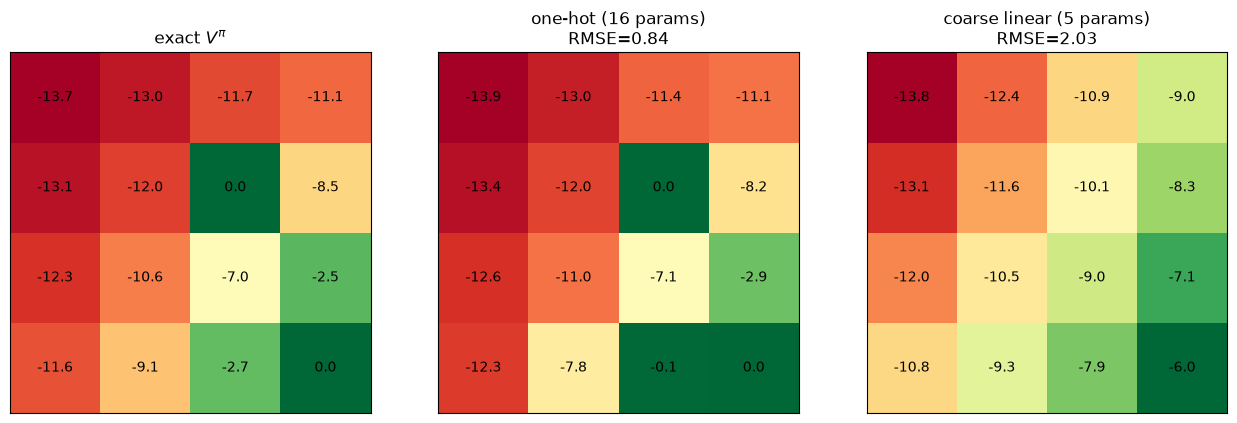

learned weights [bias, row, col, dist_goal, dist_pit]: [-7.07 -0.84  1.35 -7.33  1.1 ]


In [3]:
x_coarse = coarse_features(env)
w_coarse = semi_gradient_td0(env, x_coarse, alpha=0.01, n_episodes=8000, seed=1)
V_coarse = {s: w_coarse @ x_coarse(s) for s in env.all_states}

def rmse(V_hat):
    nonterm = [s for s in env.all_states if not env.is_terminal(s)]
    return np.sqrt(np.mean([(V_hat[s] - V_true[s]) ** 2 for s in nonterm]))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
plot_value_grid(env, V_true, "exact $V^\\pi$", ax=axes[0])
plot_value_grid(env, V_lin, f"one-hot (16 params)\nRMSE={rmse(V_lin):.2f}", ax=axes[1])
plot_value_grid(env, V_coarse, f"coarse linear (5 params)\nRMSE={rmse(V_coarse):.2f}", ax=axes[2])
plt.tight_layout(); plt.show()
print("learned weights [bias, row, col, dist_goal, dist_pit]:", np.round(w_coarse, 2))

The coarse approximation gets the broad shape right — values rise toward the
goal and dip near the pit — but it can't capture every detail. The weights are
interpretable, too: a strongly negative weight on `dist_goal` literally says
"further from the goal is worse."

Now for the property that makes function approximation worth the bias. Below,
we take **one single TD update at one single state** and look at how much the
prediction changes *everywhere*.

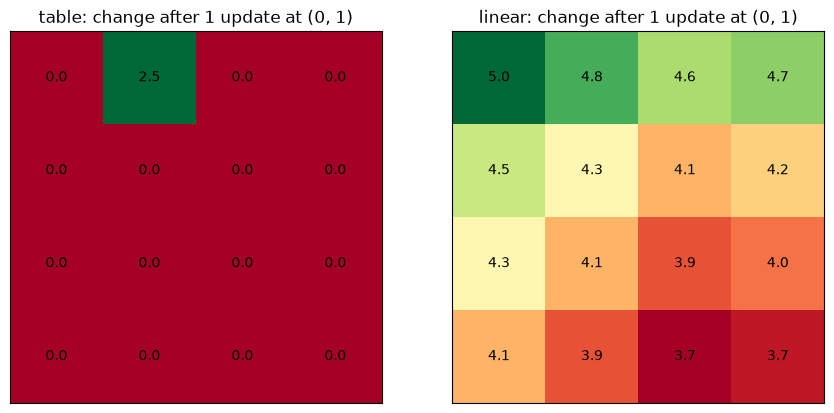

In [4]:
def one_update_footprint(feature_fn, w, s, target, alpha):
    x_s = feature_fn(s)
    w_new = w + alpha * (target - w @ x_s) * x_s
    return {q: (w_new - w) @ feature_fn(q) for q in env.all_states}

s_upd = (0, 1)
fp_tab = one_update_footprint(x_onehot, np.zeros(16), s_upd, target=5.0, alpha=0.5)
fp_lin = one_update_footprint(x_coarse, np.zeros(5), s_upd, target=5.0, alpha=0.5)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
plot_value_grid(env, fp_tab, f"table: change after 1 update at {s_upd}", ax=axes[0])
plot_value_grid(env, fp_lin, f"linear: change after 1 update at {s_upd}", ax=axes[1])
plt.tight_layout(); plt.show()

Left: the table changed one cell. Right: the linear approximator changed
**every** cell, with the biggest changes at states whose features look most
like $(0,1)$'s. That's generalization — and it's also a warning. If the update
at $(0,1)$ was *wrong*, or if the similarity implied by our features is
misleading, the error spreads everywhere too. In a table, errors stay put. In a
function approximator, they propagate.

Hand-designing features doesn't scale either: nobody can write down the right
features for "this 800-token partial answer to a chemistry question." We need
the features to be **learned**. That's what a neural network is: a function
approximator whose early layers learn the features and whose last layer is
exactly the linear model we just used.

## 3. A neural network from scratch

### Forward pass

A multi-layer perceptron (MLP) with layers $\ell = 1..L$ computes

$$
h^{(0)} = x, \qquad z^{(\ell)} = h^{(\ell-1)} W^{(\ell)} + b^{(\ell)}, \qquad h^{(\ell)} = \sigma\big(z^{(\ell)}\big)\ \ (\ell < L), \qquad \hat y = z^{(L)}.
$$

$\sigma$ is a nonlinearity — we'll support $\tanh$ and ReLU $\max(0,z)$. The
last layer has no nonlinearity, and **it is literally linear function
approximation**, with the learned $h^{(L-1)}$ playing the role of the
hand-made features $x(s)$ from Section 2.

We process a **batch** of $B$ inputs at once, so $x$ is a $B \times d_{in}$
matrix and every $h^{(\ell)}$ is $B \times d_\ell$.

### Backward pass (backpropagation), derived

Say the loss is $\mathcal L(\hat y)$ and someone hands us
$G^{(L)} = \partial \mathcal L / \partial z^{(L)}$ — a $B\times d_{out}$ matrix. (For
squared error $\tfrac1{2B}\sum(\hat y - y)^2$, that's just $(\hat y - y)/B$.)
Because $z^{(\ell)} = h^{(\ell-1)} W^{(\ell)} + b^{(\ell)}$, the chain rule gives
three facts, and those are all of backprop:

1. **Weight gradient:** each entry $W_{ij}$ multiplies $h_i$ and contributes to $z_j$, summed over the batch:
   $\;\dfrac{\partial\mathcal L}{\partial W^{(\ell)}} = \big(h^{(\ell-1)}\big)^\top G^{(\ell)}$.
2. **Bias gradient:** $b_j$ is added to $z_j$ for every row: $\;\dfrac{\partial\mathcal L}{\partial b^{(\ell)}} = \sum_{\text{batch}} G^{(\ell)}$.
3. **Send the gradient one layer back:** first through the matrix multiply,
   $\dfrac{\partial\mathcal L}{\partial h^{(\ell-1)}} = G^{(\ell)} \big(W^{(\ell)}\big)^\top$, then through the elementwise nonlinearity:
   $G^{(\ell-1)} = \dfrac{\partial\mathcal L}{\partial h^{(\ell-1)}} \odot \sigma'\big(z^{(\ell-1)}\big)$,
   with $\tanh'(z) = 1 - \tanh^2(z)$ and $\text{ReLU}'(z) = \mathbb 1[z>0]$.

Apply 1–3 from the last layer to the first. That's the whole algorithm.

One design choice matters a lot for RL: `backward` takes $G^{(L)}$ **as an
input** rather than computing it from a fixed loss. The network doesn't need to
know what loss we're using. DQN hands it a TD-error gradient, REINFORCE
(notebook 5) a policy-gradient signal, and PPO (notebook 6) a clipped-objective
gradient.

In [5]:
class MLP:
    '''
    A fully-connected network in pure numpy.
      forward(x)            -> (output, cache)
      backward(cache, dout) -> list of {"W": dW, "b": db}, one per layer
    `dout` is dLoss/dOutput -- the network does not care which loss produced it.
    '''
    def __init__(self, sizes, activation="relu", out_scale=1.0, seed=0):
        rng = np.random.default_rng(seed)
        self.activation = activation
        self.params = []
        for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:])):
            # He init for ReLU, LeCun-style for tanh: keeps activations O(1) layer after layer
            scale = np.sqrt(2.0 / n_in) if activation == "relu" else np.sqrt(1.0 / n_in)
            if i == len(sizes) - 2:
                scale *= out_scale      # optionally start with a near-zero output layer
            self.params.append({"W": rng.normal(0.0, scale, (n_in, n_out)), "b": np.zeros(n_out)})

    def _sigma(self, z):
        return np.maximum(z, 0.0) if self.activation == "relu" else np.tanh(z)

    def _sigma_prime(self, z, h):
        return (z > 0).astype(float) if self.activation == "relu" else 1.0 - h ** 2

    def forward(self, x):
        cache = [(x, None)]                        # (h, z) per layer; h^(0) = x
        h = x
        for i, p in enumerate(self.params):
            z = h @ p["W"] + p["b"]
            h = self._sigma(z) if i < len(self.params) - 1 else z   # last layer is linear
            cache.append((h, z))
        return h, cache

    def backward(self, cache, dout):
        grads = [None] * len(self.params)
        G = dout
        for i in reversed(range(len(self.params))):
            h_prev = cache[i][0]
            grads[i] = {"W": h_prev.T @ G, "b": G.sum(axis=0)}     # facts 1 and 2
            if i > 0:
                dh = G @ self.params[i]["W"].T                      # fact 3a
                h_i, z_i = cache[i]
                G = dh * self._sigma_prime(z_i, h_i)                # fact 3b
        return grads

    def predict(self, x):
        return self.forward(x)[0]

    def copy_from(self, other):
        self.params = [{k: v.copy() for k, v in p.items()} for p in other.params]

### Trust, but verify: the gradient check

Backprop code is notoriously easy to get subtly wrong: a transposed matrix or a
forgotten term, and the network still *trains*, just badly, and you'll blame
RL. The fix is to check against the definition of a derivative:

$$
\frac{\partial \mathcal L}{\partial \theta_i} \approx \frac{\mathcal L(\theta + \epsilon e_i) - \mathcal L(\theta - \epsilon e_i)}{2\epsilon}.
$$

This central difference has error $O(\epsilon^2)$. It's far too slow for
training (two forward passes *per parameter*), but perfect for a one-off test.
We compare using **relative error**, which stays meaningful whether gradients
are tiny or huge.

In [6]:
def gradient_check(net, x, y, eps=1e-6):
    def loss_of(net):
        out, _ = net.forward(x)
        return 0.5 * np.mean(np.sum((out - y) ** 2, axis=1))

    out, cache = net.forward(x)
    analytic = net.backward(cache, (out - y) / len(x))
    worst = 0.0
    for layer, g in zip(net.params, analytic):
        for key in layer:
            it = np.nditer(layer[key], flags=["multi_index"])
            for _ in it:
                i = it.multi_index
                old = layer[key][i]
                layer[key][i] = old + eps; lp = loss_of(net)
                layer[key][i] = old - eps; lm = loss_of(net)
                layer[key][i] = old
                numeric = (lp - lm) / (2 * eps)
                rel = abs(numeric - g[key][i]) / max(1e-8, abs(numeric) + abs(g[key][i]))
                worst = max(worst, rel)
    return worst

rng = np.random.default_rng(0)
x_chk, y_chk = rng.normal(size=(7, 3)), rng.normal(size=(7, 2))
for act in ["tanh", "relu"]:
    err = gradient_check(MLP([3, 5, 4, 2], activation=act, seed=1), x_chk, y_chk)
    print(f"{act:5s}: worst relative error between backprop and finite differences = {err:.2e}")
    assert err < 1e-6
print("Backprop is correct.")

tanh : worst relative error between backprop and finite differences = 3.91e-09
relu : worst relative error between backprop and finite differences = 4.70e-08
Backprop is correct.


### The optimizer: Adam, derived in three steps

Plain gradient descent is $\theta \leftarrow \theta - \alpha g$. Two things go wrong in
practice, and Adam fixes each one with a running average:

1. **Noisy gradients** (RL gradients are *very* noisy). Fix: average them over
   time with **momentum**, $m \leftarrow \beta_1 m + (1-\beta_1) g$, and step
   along $m$ instead of $g$. The noise partly cancels; the consistent direction
   accumulates.
2. **Badly scaled parameters.** Some parameters see gradients of size 100,
   others of 0.001, and one learning rate can't suit both. Fix: keep a running
   average of the *squared* gradient, $v \leftarrow \beta_2 v + (1-\beta_2) g^2$,
   and divide by $\sqrt v$. Every parameter then takes steps of roughly size
   $\alpha$, whatever its raw gradient scale.
3. **Bias correction.** $m$ and $v$ start at 0, so early on they're biased
   toward 0. After $t$ steps, $\mathbb E[m_t] = (1-\beta_1^t)\,\mathbb E[g]$, so we divide
   that factor back out: $\hat m = m/(1-\beta_1^t)$, $\hat v = v/(1-\beta_2^t)$.

$$
\theta \leftarrow \theta - \alpha\, \frac{\hat m}{\sqrt{\hat v} + \epsilon}
$$

We also add optional **gradient-norm clipping**: if the whole gradient's
L2-norm exceeds `max_norm`, rescale it down. It's a cheap safety net against
the occasional huge RL gradient, and every production RL library does it.

In [7]:
class Adam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params, self.lr, self.b1, self.b2, self.eps = params, lr, beta1, beta2, eps
        self.m = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.v = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.t = 0

    def step(self, grads, max_norm=None):
        if max_norm is not None:
            norm = np.sqrt(sum(np.sum(g[k] ** 2) for g in grads for k in g))
            if norm > max_norm:
                grads = [{k: g[k] * (max_norm / norm) for k in g} for g in grads]
        self.t += 1
        for p, g, m, v in zip(self.params, grads, self.m, self.v):
            for k in p:
                m[k] = self.b1 * m[k] + (1 - self.b1) * g[k]
                v[k] = self.b2 * v[k] + (1 - self.b2) * g[k] ** 2
                m_hat = m[k] / (1 - self.b1 ** self.t)
                v_hat = v[k] / (1 - self.b2 ** self.t)
                p[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

A quick sanity check before we mix in any RL: give the network the *exact*
$V^\pi$ from linear algebra as supervised labels, with inputs being just the
raw coordinates $(r, c)$ — **no hand-designed features at all**. If our MLP and
Adam are right, the network should discover whatever features it needs by
itself, and beat the 5-feature linear model from Section 2.

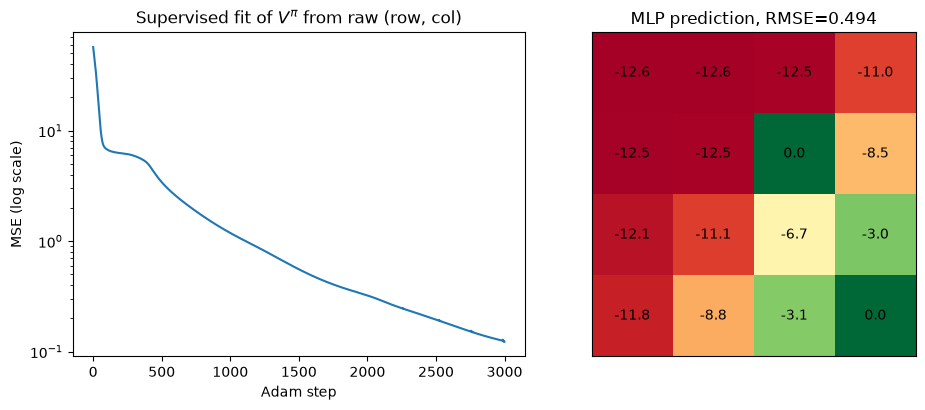

In [8]:
nonterminal = [s for s in env.all_states if not env.is_terminal(s)]
X = np.array([[r / 3, c / 3] for (r, c) in nonterminal])
Y = np.array([[V_true[s]] for s in nonterminal])

net = MLP([2, 32, 32, 1], activation="tanh", seed=0)
opt = Adam(net.params, lr=3e-3)
losses = []
for it in range(3000):
    out, cache = net.forward(X)
    losses.append(0.5 * np.mean((out - Y) ** 2))
    opt.step(net.backward(cache, (out - Y) / len(X)))

V_mlp = {s: 0.0 for s in env.all_states}
V_mlp.update({s: net.predict(np.array([[s[0] / 3, s[1] / 3]]))[0, 0] for s in nonterminal})

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].semilogy(losses); axes[0].set_xlabel("Adam step"); axes[0].set_ylabel("MSE (log scale)")
axes[0].set_title("Supervised fit of $V^\\pi$ from raw (row, col)")
plot_value_grid(env, V_mlp, f"MLP prediction, RMSE={rmse(V_mlp):.3f}", ax=axes[1])
plt.tight_layout(); plt.show()

From nothing but raw coordinates, the MLP learns an almost perfect $V^\pi$.
It found its own features. The machinery works.

But this was **supervised** learning: we gave it the right answers. In RL
there are no right answers, only bootstrapped targets that move as we learn.
That's where things get interesting — and where we need an environment that
actually *needs* a neural network.

## 4. CartPole: a continuous-state problem, from its physics

A cart moves along a frictionless track with a pole hinged on top. Each step
(0.02 s) the agent pushes the cart **left or right** with a fixed force. Reward
is $+1$ for every step the pole stays up. The episode **terminates** if the
pole tilts more than 12° or the cart leaves the track ($|x| > 2.4$), and is
**truncated** after 500 steps. The state is four real numbers:

$$
s = (x,\ \dot x,\ \theta,\ \dot\theta) \quad = \quad (\text{cart position, cart velocity, pole angle, pole angular velocity}).
$$

Why this environment? A table is hopeless here (the state is continuous), yet
it's small enough that a numpy network learns it in seconds. It's also the
standard "hello world" of deep RL — notebooks 5 and 6 reuse it, and notebook 10
runs the exact same task through `gymnasium` to show the production version.

### The physics (skim it — the point is that there is no magic)

These are the classic equations of motion (Barto, Sutton & Anderson, 1983).
With push force $F = \pm 10$ N, gravity $g$, cart mass $m_c$, pole mass $m_p$,
half-pole length $l$:

$$
\ddot\theta = \frac{g\sin\theta - \cos\theta\cdot \frac{F + m_p l \dot\theta^2 \sin\theta}{m_c + m_p}}{l\left(\frac43 - \frac{m_p\cos^2\theta}{m_c + m_p}\right)},
\qquad
\ddot x = \frac{F + m_p l \dot\theta^2\sin\theta}{m_c+m_p} - \frac{m_p l\, \ddot\theta \cos\theta}{m_c + m_p},
$$

integrated with one Euler step per timestep. One important distinction
(inherited from `gymnasium`) will matter for correctness later:

- **terminated** = the pole fell. The future really is over, so the value of
  what comes next is **0**.
- **truncated** = we hit the 500-step time limit. The pole was still up. The
  future is *not* worth 0 — we just stopped watching. When bootstrapping, we
  must still use $\gamma \hat V(s')$ here. Mixing these up is one of the most
  common bugs in real RL code.

In [9]:
class CartPole:
    '''CartPole-v1 dynamics in pure numpy (same constants as gymnasium).'''
    n_actions = 2
    obs_dim = 4

    def __init__(self, max_steps=500, seed=None):
        self.gravity, self.m_cart, self.m_pole, self.half_len = 9.8, 1.0, 0.1, 0.5
        self.force_mag, self.dt = 10.0, 0.02
        self.x_limit, self.theta_limit = 2.4, 12 * 2 * np.pi / 360
        self.max_steps = max_steps
        self.rng = np.random.default_rng(seed)

    def reset(self):
        self.state = self.rng.uniform(-0.05, 0.05, size=4)
        self.t = 0
        return self.state.copy()

    def step(self, action):
        x, x_dot, th, th_dot = self.state
        force = self.force_mag if action == 1 else -self.force_mag
        cos_t, sin_t = np.cos(th), np.sin(th)
        total_m = self.m_cart + self.m_pole
        pml = self.m_pole * self.half_len
        temp = (force + pml * th_dot ** 2 * sin_t) / total_m
        th_acc = (self.gravity * sin_t - cos_t * temp) / (
            self.half_len * (4.0 / 3.0 - self.m_pole * cos_t ** 2 / total_m))
        x_acc = temp - pml * th_acc * cos_t / total_m
        # Euler integration
        x, x_dot = x + self.dt * x_dot, x_dot + self.dt * x_acc
        th, th_dot = th + self.dt * th_dot, th_dot + self.dt * th_acc
        self.state = np.array([x, x_dot, th, th_dot])
        self.t += 1
        terminated = bool(abs(x) > self.x_limit or abs(th) > self.theta_limit)
        truncated = self.t >= self.max_steps
        return self.state.copy(), 1.0, terminated, truncated

def run_episode(env, policy_fn):
    s, total = env.reset(), 0.0
    while True:
        s, r, terminated, truncated = env.step(policy_fn(s))
        total += r
        if terminated or truncated:
            return total

cp = CartPole(seed=0)
rng = np.random.default_rng(0)
random_returns = [run_episode(cp, lambda s: rng.integers(2)) for _ in range(200)]
# A hand-written rule: push in the direction the pole is falling.
rule_returns = [run_episode(cp, lambda s: int(s[2] + 0.5 * s[3] > 0)) for _ in range(200)]
print(f"random policy      : mean episode length {np.mean(random_returns):6.1f}")
print(f"'push toward fall' : mean episode length {np.mean(rule_returns):6.1f}   (max possible 500)")

random policy      : mean episode length   22.5
'push toward fall' : mean episode length  500.0   (max possible 500)


A random policy lasts about 20 steps. The one-line heuristic "push in the
direction the pole is falling" balances for the full 500. So the problem has
simple structure — *if you already know the physics*. The agent doesn't. It
sees four unlabeled numbers and a +1 per step, and must discover the rule from
reward alone. That's our goal: reach **500** without being told anything.

## 5. Deep Q-learning, naively — and why it falls apart

Take notebook 3's Q-learning, replace the table with an MLP that maps a state
to **one Q-value per action** (4 inputs → 2 outputs), and use the semi-gradient
update from Section 2. For a transition $(s, a, r, s', \text{term})$:

$$
y = r + \gamma\,(1-\text{term}) \max_{a'} Q_w(s', a') \quad(\text{held constant}), \qquad
\mathcal L(w) = \tfrac12 \big(Q_w(s,a) - y\big)^2 .
$$

The gradient with respect to the network's output vector is zero except at
action $a$, where it is $Q_w(s,a) - y$. We pass exactly that as `dout` to
`MLP.backward`.

Everything below uses a single `dqn` function with switches, so we can turn
each fix on and off and see what it contributes. First, **all switches off**:
learn online from each transition once, immediately, then throw it away —
exactly like tabular Q-learning.

In [10]:
class ReplayBuffer:
    '''Fixed-size circular buffer of transitions; samples uniform random minibatches.'''
    def __init__(self, capacity, obs_dim, seed=0):
        self.S = np.zeros((capacity, obs_dim)); self.S2 = np.zeros((capacity, obs_dim))
        self.A = np.zeros(capacity, dtype=int); self.R = np.zeros(capacity); self.TERM = np.zeros(capacity)
        self.capacity, self.ptr, self.size = capacity, 0, 0
        self.rng = np.random.default_rng(seed)

    def add(self, s, a, r, s2, terminated):
        i = self.ptr
        self.S[i], self.A[i], self.R[i], self.S2[i], self.TERM[i] = s, a, r, s2, float(terminated)
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idx = self.rng.integers(0, self.size, size=batch_size)
        return self.S[idx], self.A[idx], self.R[idx], self.S2[idx], self.TERM[idx]

    def latest(self):
        i = (self.ptr - 1) % self.capacity
        return self.S[i:i+1], self.A[i:i+1], self.R[i:i+1], self.S2[i:i+1], self.TERM[i:i+1]


def greedy_eval(q_net, n_episodes=5, seed=123):
    env = CartPole(seed=seed)
    return np.mean([run_episode(env, lambda s: int(np.argmax(q_net.predict(s[None])[0])))
                    for _ in range(n_episodes)])


def dqn(total_steps=50_000, use_replay=True, use_target=True, double=False,
        gamma=0.99, lr=1e-3, batch_size=64, buffer_size=50_000, learn_start=1000,
        tau=0.01, eps_decay_steps=10_000, eval_every=2500, seed=0):
    rng = np.random.default_rng(seed)
    env = CartPole(seed=seed)
    q = MLP([4, 64, 64, 2], activation="relu", seed=seed)
    q_target = MLP([4, 64, 64, 2], activation="relu"); q_target.copy_from(q)
    opt = Adam(q.params, lr=lr)
    buf = ReplayBuffer(buffer_size, 4, seed=seed)

    log = {"step": [], "greedy_return": [], "q_start": []}
    s = env.reset()
    for t in range(total_steps):
        # ---- act: epsilon-greedy, epsilon decays linearly 1.0 -> 0.05 ----
        eps = max(0.05, 1.0 - t / eps_decay_steps)
        a = int(rng.integers(2)) if rng.random() < eps else int(np.argmax(q.predict(s[None])[0]))
        s2, r, terminated, truncated = env.step(a)
        buf.add(s, a, r, s2, terminated)          # store `terminated`, NOT `truncated`
        s = env.reset() if (terminated or truncated) else s2

        if (t + 1) % eval_every == 0:
            log["step"].append(t + 1)
            log["greedy_return"].append(greedy_eval(q))
            log["q_start"].append(q.predict(np.zeros((1, 4)))[0].max())

        # ---- learn ----
        if use_replay:
            if buf.size < learn_start:
                continue
            S, A, R, S2, TERM = buf.sample(batch_size)
        else:
            S, A, R, S2, TERM = buf.latest()          # the one transition we just saw

        bootstrap_net = q_target if use_target else q
        q_next = bootstrap_net.predict(S2)
        if double:   # choose a' with the ONLINE net, evaluate it with the TARGET net
            a_star = np.argmax(q.predict(S2), axis=1)
            next_v = q_next[np.arange(len(A)), a_star]
        else:
            next_v = q_next.max(axis=1)
        y = R + gamma * (1.0 - TERM) * next_v        # a constant: no gradient flows into y

        out, cache = q.forward(S)
        td_err = out[np.arange(len(A)), A] - y
        dout = np.zeros_like(out)
        dout[np.arange(len(A)), A] = td_err / len(A)  # d(0.5*mean err^2)/d out
        opt.step(q.backward(cache, dout), max_norm=10.0)

        if use_target:   # "soft"/Polyak update: target slowly tracks the online net
            for pt, p in zip(q_target.params, q.params):
                for k in p:
                    pt[k] = (1 - tau) * pt[k] + tau * p[k]
    return log, q

t0 = time.time()
naive_logs = [dqn(use_replay=False, use_target=False, seed=sd)[0] for sd in range(3)]
print(f"naive online deep Q-learning, 3 seeds: {time.time() - t0:.0f}s")
for sd, lg in enumerate(naive_logs):
    print(f"  seed {sd}: greedy return over training ->", [int(x) for x in lg["greedy_return"]])

naive online deep Q-learning, 3 seeds: 25s
  seed 0: greedy return over training -> [9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]
  seed 1: greedy return over training -> [9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]
  seed 2: greedy return over training -> [9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]


It doesn't learn at all. In every seed, the greedy policy collapsed to "always
push the same way," which knocks the pole over in 9 steps. Tabular Q-learning,
with the exact same update rule, worked perfectly in notebook 3. What changed? Sutton & Barto name the culprit the
**deadly triad**. Instability becomes likely when **all three** of these are
present at once:

1. **Function approximation** — updates to one state change the values of
   others (Section 2's "footprint" picture).
2. **Bootstrapping** — targets are built from our own current estimates,
   $y = r + \gamma \max Q_w(s',\cdot)$.
3. **Off-policy learning** — we learn about the greedy policy while collecting
   data with an $\epsilon$-greedy one, so the data distribution doesn't match
   the policy being evaluated.

Put (1) and (2) together and you get a feedback loop. Increasing $Q_w(s,a)$
also increases $Q_w(s',\cdot)$ (because $s$ and $s'$ are similar — in
CartPole, consecutive states are *nearly identical*). That raises the target,
so the next update pushes $Q_w(s,a)$ up again. The network is chasing its own
tail. Two practical aggravations make it worse:

- **Correlated samples.** Consecutive transitions are nearly identical, so
  online SGD takes hundreds of steps in the *same* direction. The network
  over-fits to the current part of the state space and forgets the rest
  (**catastrophic forgetting**).
- **A moving target.** Every update to $w$ moves $y$ as well — like a
  supervised-learning problem whose labels change after every gradient step.

## 6. The two fixes that made DQN work

Mnih et al. (2015) — the paper that learned Atari from pixels — added two
ingredients, one per aggravation above:

**Experience replay.** Store every transition in a big buffer and train on
**random minibatches** drawn from it. Random sampling breaks the correlation
between consecutive samples (the minibatch looks roughly i.i.d., the way SGD
likes it). Each transition gets reused many times, which improves sample
efficiency. Note that replay is only possible *because* Q-learning is
off-policy: the buffer contains data from old policies, and Q-learning's
target doesn't care which policy produced the data. (Keep this in mind — in
notebook 5, policy gradients will lose this ability, and notebook 6 is about
getting part of it back.)

**Target network.** Keep a second, slowly-updated copy of the network,
$Q_{\bar w}$, and compute targets with it: $y = r + \gamma \max_{a'} Q_{\bar w}(s',a')$.
The labels now stay (almost) still while the online network fits them, which
breaks the feedback loop. The original DQN copied $\bar w \leftarrow w$ every
$C$ steps. We use the smoother **Polyak** update
$\bar w \leftarrow (1-\tau)\bar w + \tau w$ with $\tau = 0.01$ each step.

(The original DQN also used a **Huber loss** — quadratic for small errors,
linear for large ones — so a single huge TD error can't produce a huge
gradient. We get a similar safety effect from gradient-norm clipping in
`Adam.step`.)

Let's add the fixes one at a time and look at the ablation.

ablation runs: 74s


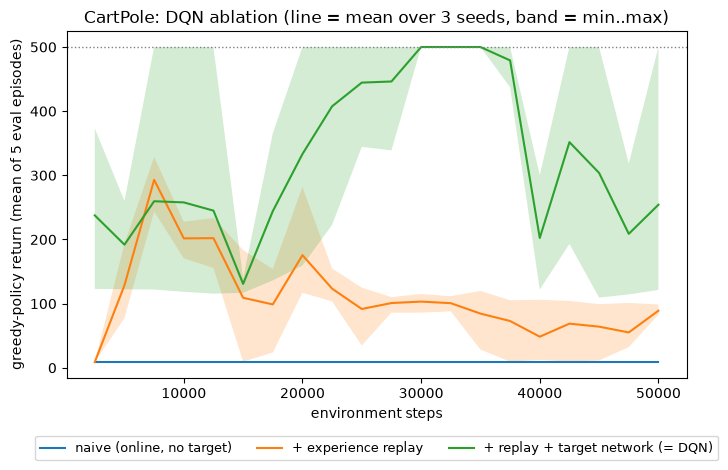

DQN seed 0: best greedy return 500, final 141
DQN seed 1: best greedy return 500, final 500
DQN seed 2: best greedy return 500, final 121


In [11]:
t0 = time.time()
replay_logs = [dqn(use_replay=True, use_target=False, seed=sd)[0] for sd in range(3)]
full_runs = [dqn(use_replay=True, use_target=True, seed=sd) for sd in range(3)]
full_logs = [lg for lg, _ in full_runs]
print(f"ablation runs: {time.time() - t0:.0f}s")

def plot_band(ax, logs, key, label):
    steps = logs[0]["step"]
    arr = np.array([lg[key] for lg in logs])
    ax.plot(steps, arr.mean(0), label=label)
    ax.fill_between(steps, arr.min(0), arr.max(0), alpha=0.2)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_band(ax, naive_logs, "greedy_return", "naive (online, no target)")
plot_band(ax, replay_logs, "greedy_return", "+ experience replay")
plot_band(ax, full_logs, "greedy_return", "+ replay + target network (= DQN)")
ax.axhline(500, color="gray", ls=":", lw=1)
ax.set_xlabel("environment steps"); ax.set_ylabel("greedy-policy return (mean of 5 eval episodes)")
ax.set_title("CartPole: DQN ablation (line = mean over 3 seeds, band = min..max)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=9); plt.show()

for sd, lg in enumerate(full_logs):
    print(f"DQN seed {sd}: best greedy return {max(lg['greedy_return']):.0f}, "
          f"final {lg['greedy_return'][-1]:.0f}")

Some things to notice (your exact numbers will depend on the seed):

- **Replay alone is not enough** here. It learns something early, then
  degrades as it chases its own tail. With **both** fixes, every seed reaches
  the full 500 steps at some point.
- **Even full DQN is jumpy.** Performance reaches 500 and then sometimes drops
  sharply before recovering. This is real, well-known DQN behavior, not a bug
  in our code: when the replay buffer fills up with "pole balanced" states, the
  network slowly forgets what to do in rare "pole falling" states, and the
  policy degrades until those states show up again. In practice, people
  **evaluate periodically and keep the best checkpoint**. And "unstable,
  sensitive to hyperparameters" is one reason the field moved toward the
  policy-gradient methods of notebooks 5–6.

## 7. Overestimation bias, and Double Q-learning

There's one more systematic problem, hiding inside the $\max$ in the target.
Suppose every action's true value is 0, but our estimates carry zero-mean
noise: $\hat Q(a) = 0 + \varepsilon_a$. Each estimate is **unbiased**. Their
max is not:

$$
\mathbb E\big[\max_a \hat Q(a)\big] \;\ge\; \max_a \mathbb E\big[\hat Q(a)\big] = 0 .
$$

(This is Jensen's inequality, since max is convex.) Intuition: the max
*selects* whichever estimate happened to be noisiest in the upward direction,
and then *reports that same noisy number* as the value. Selection and
evaluation use the same noise, so the noise doesn't average out — it gets
picked. Let's measure how big this is.

In [12]:
rng = np.random.default_rng(0)
print("true value of every action = 0; each estimate = true + N(0, 1) noise")
for n_actions in [2, 4, 10, 100, 1000]:
    noisy = rng.normal(0, 1, size=(20000, n_actions))
    print(f"  {n_actions:5d} actions: E[max of estimates] = {noisy.max(axis=1).mean():.3f}")

true value of every action = 0; each estimate = true + N(0, 1) noise
      2 actions: E[max of estimates] = 0.570
      4 actions: E[max of estimates] = 1.025
     10 actions: E[max of estimates] = 1.545
    100 actions: E[max of estimates] = 2.508


   1000 actions: E[max of estimates] = 3.244


With 10 actions the bias is already about $+1.5$ noise standard deviations,
and it grows with the number of actions. (An LLM "action space" has ~100,000
tokens — keep that in mind for Section 8.) In Q-learning this bias doesn't
stay put: it is **bootstrapped** into the previous state's target, then the
one before, compounding backward through time.

**The fix: decouple selection from evaluation.** Keep two independent
estimates $Q^A, Q^B$. Use one to *choose* the action and the other to
*evaluate* it:

$$
y = r + \gamma\, Q^B\big(s', \arg\max_{a'} Q^A(s', a')\big).
$$

If $Q^A$'s noise picked a lucky action, $Q^B$'s noise on that action is
independent, so on average it reports the true value. This is **Double
Q-learning** (van Hasselt, 2010). The classic demonstration (Sutton & Barto,
Example 6.7) is a tiny MDP designed to trap plain Q-learning:

- From start state **A**: `right` ends the episode with reward 0. `left` goes to
  state **B** with reward 0.
- From **B**: any of 10 actions ends the episode with reward drawn from
  $\mathcal N(-0.1, 1)$.

Going `left` is **wrong** on average ($-0.1 < 0$). But $\max$ over B's 10 noisy
estimates looks *positive* early on, so Q-learning is lured left.

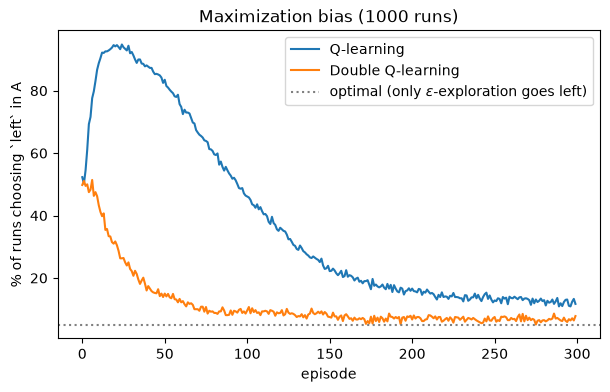

In [13]:
def maximization_bias_experiment(double, n_runs=1000, n_episodes=300, alpha=0.1, eps=0.1, n_b=10, seed=0):
    rng = np.random.default_rng(seed)
    went_left = np.zeros(n_episodes)

    def eps_greedy(q_values):
        if rng.random() < eps:
            return int(rng.integers(len(q_values)))
        return int(rng.choice(np.flatnonzero(q_values == q_values.max())))   # random tie-break

    for _ in range(n_runs):
        # Q["A"] = [Q(A,left), Q(A,right)],  Q["B"] = 10 action values in state B
        QA = {"A": np.zeros(2), "B": np.zeros(n_b)}
        QB = {"A": np.zeros(2), "B": np.zeros(n_b)}      # only used by Double Q-learning
        for ep in range(n_episodes):
            # Behaviour: plain Q-learning acts on QA; Double Q-learning acts on QA + QB.
            a = eps_greedy(QA["A"] + QB["A"] if double else QA["A"])
            went_left[ep] += (a == 0)

            # Which table gets this update?  Plain: always QA.  Double: a fair coin.
            upd, other = (QA, QB) if (not double or rng.random() < 0.5) else (QB, QA)
            if a == 1:                         # right -> terminal, reward 0
                target = 0.0
            elif not double:                   # left -> B, reward 0, bootstrap with max
                target = QA["B"].max()
            else:                              # SELECT with `upd`, EVALUATE with `other`
                target = other["B"][np.argmax(upd["B"])]
            upd["A"][a] += alpha * (target - upd["A"][a])

            if a == 0:                         # now in B: any action ends with N(-0.1, 1)
                b = eps_greedy(QA["B"] + QB["B"] if double else QA["B"])
                r = rng.normal(-0.1, 1.0)
                upd, _ = (QA, QB) if (not double or rng.random() < 0.5) else (QB, QA)
                upd["B"][b] += alpha * (r - upd["B"][b])
    return went_left / n_runs

frac_q = maximization_bias_experiment(double=False)
frac_dq = maximization_bias_experiment(double=True)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(frac_q * 100, label="Q-learning")
ax.plot(frac_dq * 100, label="Double Q-learning")
ax.axhline(5, color="gray", ls=":", label="optimal (only $\\epsilon$-exploration goes left)")
ax.set_xlabel("episode"); ax.set_ylabel("% of runs choosing `left` in A")
ax.set_title("Maximization bias (1000 runs)"); ax.legend(); plt.show()

Q-learning goes the wrong way far more than it should early on, fooled by the
optimistic max, and takes a long time to recover. Double Q-learning stays close
to the optimal rate from the start.

**Double DQN** (van Hasselt et al., 2016) applies the same idea at essentially
zero cost: we *already have* two networks. Select with the online network and
evaluate with the target network:

$$
y = r + \gamma\, Q_{\bar w}\big(s', \arg\max_{a'} Q_w(s',a')\big).
$$

That's the `double=True` branch in our `dqn` function — a two-line change. We
can also check for overestimation directly. The reward is $+1$ per step, and
we bootstrap through truncation (correctly — see Section 4), so the network is
estimating an *infinite-horizon* discounted return. No policy can ever earn
more than $\sum_{k=0}^{\infty} 0.99^k = 1/(1-0.99) = 100$. Any predicted
$\max_a Q(s_0,a)$ above 100 is therefore **provably** an overestimate.

Double DQN runs: 360s


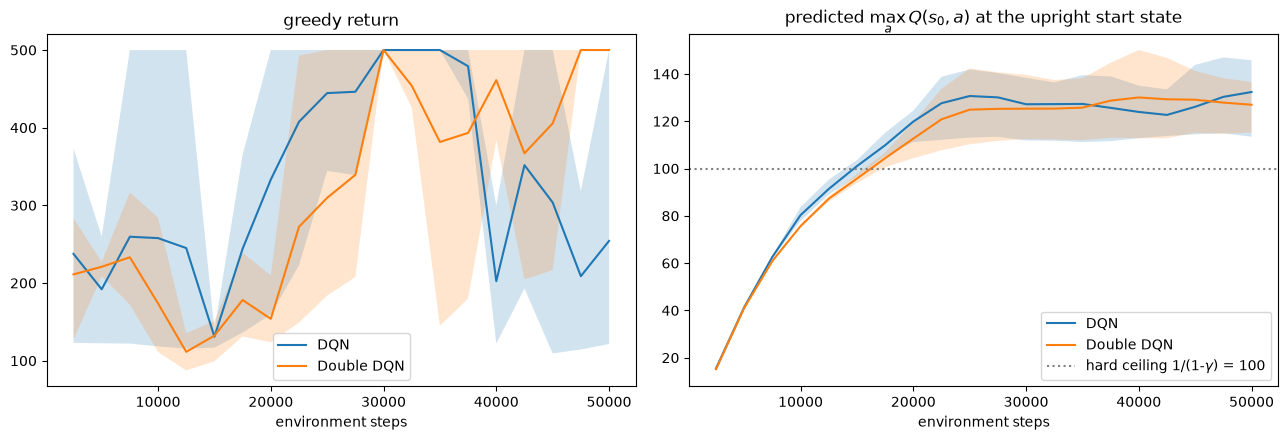

mean predicted Q(s0) over the last 5 evals:  DQN 127.1   Double DQN 128.7   (ceiling 100.0)


In [14]:
t0 = time.time()
ddqn_logs = [dqn(double=True, seed=sd)[0] for sd in range(3)]
print(f"Double DQN runs: {time.time() - t0:.0f}s")
true_max = 1 / (1 - 0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_band(axes[0], full_logs, "greedy_return", "DQN")
plot_band(axes[0], ddqn_logs, "greedy_return", "Double DQN")
axes[0].set_title("greedy return"); axes[0].set_xlabel("environment steps"); axes[0].legend()
plot_band(axes[1], full_logs, "q_start", "DQN")
plot_band(axes[1], ddqn_logs, "q_start", "Double DQN")
axes[1].axhline(true_max, color="gray", ls=":", label=f"hard ceiling 1/(1-$\\gamma$) = {true_max:.0f}")
axes[1].set_title("predicted $\\max_a Q(s_0, a)$ at the upright start state")
axes[1].set_xlabel("environment steps"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"mean predicted Q(s0) over the last 5 evals:  DQN {np.mean([lg['q_start'][-5:] for lg in full_logs]):.1f}"
      f"   Double DQN {np.mean([lg['q_start'][-5:] for lg in ddqn_logs]):.1f}   (ceiling {true_max:.1f})")

Look at the right-hand panel. Everything above the dotted line is impossible,
yet **both** networks predict above it. And here Double DQN does *not* visibly
fix it. That's an honest and useful result, so let's understand it rather than
tune it away:

- Double DQN removes one specific error: the **selection bias** of the max. On
  CartPole there are only **two** actions, so that bias is small (about $0.57\sigma$
  per step in our table above, versus $1.5\sigma$ for 10 actions). The tabular
  experiment, with 10 actions in B, showed a much bigger effect.
- The remaining overestimation comes from other sources Double DQN doesn't
  address. The main one is **generalization under function approximation**:
  states near the start are visited constantly, and every update that raises
  them also raises their neighbours' values, which feed back into the targets
  (the deadly-triad loop from Section 5, slowed by the target network rather
  than eliminated).

The takeaway is the mechanism: **a max over noisy estimates is biased upward,
bootstrapping compounds it, and a learned value is not ground truth.**

This is our first encounter with a theme that becomes central in LLM RL:
*an optimizer that maximizes against a noisy or imperfect estimate will find
and exploit its errors.* In RLHF (notebook 7) the "noisy estimate" is a learned
reward model and the exploitation is called **reward hacking**. Notebook 6
builds the main defense against it: a KL penalty that keeps the policy close
to a reference model.

## 8. Why DQN is not how LLMs are trained — and what carries over anyway

It's natural to ask: an LLM picks a token from a finite vocabulary, so why not
make the LLM output $Q(s, \text{token})$ and act greedily? Several reasons,
each pointing to the next notebook:

1. **The LLM already *is* a policy.** Pretraining gives us a network that
   outputs a probability distribution $\pi(\text{token}\mid\text{context})$
   — a very good one. We don't want to throw that away and learn $Q$-values
   from scratch. We want to *nudge the distribution we already have*. That calls
   for methods that parametrize and update **the policy directly**: policy
   gradients, notebook 5.
2. **Stochastic output is a feature.** We want diverse, sampled responses, not
   the single argmax response to every prompt. Policy-based methods learn
   stochastic policies naturally. Value-based methods get stochasticity only
   through a bolted-on $\epsilon$.
3. **Huge action spaces make the max problematic.** With ~$10^5$ tokens, the
   maximization bias from Section 7 grows (bigger max over noisier estimates),
   and $\epsilon$-greedy exploration over $10^5$ actions is hopeless.
4. **Sequence-level reward.** As notebook 1 showed, LLM rewards usually arrive
   once, at the end. Bootstrapping $Q$ through hundreds of reward-0 tokens is
   exactly the long, compounding bootstrap chain the deadly triad punishes.

**What *does* carry directly into LLM RL** — practically everything else in
this notebook:

- **Neural function approximation trained by regression on targets.** The
  **value head / critic** in PPO for LLMs (notebooks 6–7) is precisely
  $\hat V_w(s)$: a network trained to regress onto bootstrapped or Monte Carlo
  targets with a squared-error loss — Section 2's semi-gradient update, at
  scale. And a **reward model** (notebook 7) is a function approximator too,
  trained on preference labels instead of returns.
- **"Stop the gradient through the target"** (`.detach()`) appears in every
  critic loss.
- **Stability tricks** — gradient clipping, Adam, slowly-moving reference
  copies of a network, and suspicion of any number obtained by optimizing
  against an estimate.
- **Terminated vs. truncated** — hitting max generation length is a
  *truncation*, and the distinction matters for LLM critics too.

The production PyTorch version of this notebook — `nn.Module`, autograd
replacing our `backward`, `torch.optim.Adam`, and a CleanRL-style DQN on
gymnasium's CartPole — lives in **notebook 10**, where we map each line back
to the numpy code here.

## 9. Recap, and what's next

**What we derived and built, from first principles:**

- Why tables fail: not just memory, but **zero generalization**.
- Linear function approximation and **semi-gradient TD(0)**: derived from
  squared-error regression by substituting the TD target for the true value,
  and "semi" because the target is treated as a constant.
- A proof by experiment that **tabular TD is linear TD with one-hot features**,
  and a picture of how a single update spreads across all states under
  function approximation.
- An **MLP with backpropagation** derived from three chain-rule facts,
  verified by a finite-difference gradient check, plus **Adam** built up from
  momentum, RMS scaling and bias correction.
- **CartPole** from its equations of motion, and the terminated-vs-truncated
  distinction.
- **Deep Q-learning**: why the naive version fails (the **deadly triad**:
  function approximation + bootstrapping + off-policy), and how **experience
  replay** and a **target network** fix it, shown with an ablation.
- **Maximization bias** measured directly, and **Double Q-learning / Double
  DQN** as the fix.

**The gap we're leaving open:** DQN learns *values* and derives a policy by
argmax. For LLMs we want to improve a stochastic policy **directly** — the
pretrained model's own token distribution. **Notebook 5: Policy Gradients**
derives how to compute the gradient of expected reward with respect to a
policy's parameters, using only samples and no model of the environment, and
uses it to "fine-tune" our tiny token-generating environment from notebook 1.

### Exercises

1. **Hard vs. soft target updates.** Replace the Polyak update with a hard
   copy $\bar w \leftarrow w$ every $C$ steps, for $C \in \{100, 500, 2000\}$. How does
   stability change? What happens as $C \to 1$ (which should recover the
   "no target network" behavior)?
2. **Terminated vs. truncated bug.** Deliberately store `terminated or
   truncated` in the replay buffer instead of `terminated`, so that reaching
   step 500 looks like a failure. What happens to the predicted $Q(s_0)$, and
   to performance near 500 steps? Why?
3. **Feature engineering vs. learning.** Train linear semi-gradient TD on
   CartPole (to evaluate a fixed policy, e.g. the "push toward fall" rule)
   with features $[1, x, \dot x, \theta, \dot\theta]$, then add pairwise
   products. How much do the richer features help? How does this compare to
   letting an MLP learn its own features?
4. **Bigger action spaces.** Modify the maximization-bias MDP so state B has
   100 actions instead of 10. How much worse does plain Q-learning get? Relate
   your answer to the LLM "action space" discussion in Section 8.